# Data Visualisation Project: Analysis and Visualisation of Football Player Market Values

# Preliminary Visualisation and Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make the shared helpers in src/ importable from the notebooks/ folder
import sys
sys.path.append("..")
from src.plotting import GREEN_SCALE, plot_count_bars, plot_missing_values


In [2]:
# Load the dataset
df = pd.read_csv("../data/fifa_players.csv")

In [5]:
# Display the first 5 rows of the dataset
df.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [6]:
# Display all columns
pd.set_option('display.max_columns', None)
df

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,wage_euro,preferred_foot,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),body_type,release_clause_euro,national_team,national_rating,national_team_position,national_jersey_number,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,565000.0,Left,5,4,4,Messi,226500000.0,Argentina,82.0,RF,10.0,86,95,70,92,86,97,93,94,89,96,91,86,93,95,95,85,68,72,66,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,205000.0,Right,3,5,4,Lean,133800000.0,Denmark,78.0,CAM,10.0,88,81,52,91,80,84,86,87,89,91,76,73,80,88,81,84,50,92,58,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,255000.0,Right,4,4,5,Normal,144200000.0,France,84.0,RDM,6.0,80,75,75,86,85,87,85,82,90,90,71,79,76,82,66,90,83,88,87,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,165000.0,Right,3,4,4,Normal,105400000.0,Italy,83.0,LW,10.0,86,77,56,85,74,90,87,77,78,93,94,86,94,83,93,75,53,75,44,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,60000000.0,135000.0,Right,3,3,2,Normal,106500000.0,NaN,NaN,NaN,NaN,30,22,83,68,14,69,28,28,60,63,70,75,50,82,40,55,81,75,94,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,975000.0,3000.0,Right,1,3,3,Normal,1800000.0,NaN,NaN,NaN,NaN,57,61,60,66,37,64,53,47,61,66,83,86,93,63,82,51,77,75,64,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,190000.0,1000.0,Left,1,3,2,Normal,295000.0,NaN,NaN,NaN,NaN,50,19,53,55,31,52,26,28,43,53,70,64,54,50,53,27,74,66,70,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,170000.0,1000.0,Right,1,1,1,Normal,289000.0,NaN,NaN,NaN,NaN,11,9,13,26,9,12,13,12,24,18,27,22,29,48,38,17,43,25,63,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,280000.0,4000.0,Right,1,4,3,Lean,532000.0,NaN,NaN,NaN,NaN,42,60,55,49,49,57,47,39,37,56,84,86,65,53,73,56,58,58,49,58,38,15,54,52,50,53,16,18,17


In [7]:
# Dataset dimensions

df.shape

(17954, 51)

In [8]:
# Display the data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

In [9]:
# General statistics

df.describe()

,age,height_cm,weight_kgs,overall_rating,potential,value_euro,wage_euro,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),release_clause_euro,national_rating,national_jersey_number,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
count,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,1.769900e+04,17708.000000,17954.000000,17954.000000,17954.000000,1.611700e+04,857.000000,857.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000
mean,25.565445,174.946921,75.301047,66.240169,71.430935,2.479280e+06,9902.134628,1.111674,2.945695,2.361034,4.622522e+06,76.341890,12.456243,49.697672,45.358249,52.148212,58.566058,42.755208,55.278991,47.101147,42.688092,52.667428,58.223906,64.696224,64.803498,63.377465,61.821878,63.870057,55.319873,64.955219,63.133842,65.158850,46.852456,55.816531,46.657959,49.857302,53.406260,48.357302,58.680183,47.162861,47.733040,45.705915
std,4.705708,14.029449,7.083684,6.963730,6.131339,5.687014e+06,21995.593750,0.392168,0.663691,0.763223,1.129077e+07,4.786667,8.098157,18.483310,19.640792,17.521819,14.863178,17.802936,19.091876,18.536621,17.565634,15.421545,16.875717,15.001345,14.722750,14.806946,9.075675,14.174038,17.351295,11.705711,15.917554,12.535955,19.429337,17.394047,20.754649,19.694311,14.156038,15.810844,11.625541,20.037346,21.674973,21.285812
min,17.000000,152.400000,49.900000,47.000000,48.000000,1.000000e+04,1000.000000,1.000000,1.000000,1.000000,1.300000e+04,63.000000,1.000000,5.000000,2.000000,4.000000,7.000000,3.000000,4.000000,6.000000,3.000000,9.000000,5.000000,12.000000,12.000000,11.000000,24.000000,16.000000,2.000000,15.000000,12.000000,20.000000,3.000000,11.000000,3.000000,2.000000,10.000000,5.000000,12.000000,3.000000,2.000000,3.000000
25%,22.000000,154.940000,69.900000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,2.000000,5.250000e+05,73.000000,6.000000,38.000000,30.000000,44.000000,53.000000,30.000000,49.000000,34.000000,30.000000,43.000000,54.000000,57.000000,58.000000,55.000000,56.000000,56.000000,45.000000,58.000000,56.000000,58.000000,32.000000,44.000000,26.000000,38.000000,44.000000,38.000000,51.000000,30.000000,27.000000,24.000000
50%,25.000000,175.260000,74.800000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,2.000000,1.200000e+06,75.000000,12.000000,54.000000,49.000000,56.000000,62.000000,44.000000,61.000000,49.000000,41.000000,56.000000,63.000000,67.000000,67.000000,66.000000,62.000000,66.000000,59.000000,66.000000,66.000000,66.000000,51.000000,59.000000,52.000000,55.000000,55.000000,49.000000,60.000000,52.500000,55.000000,52.000000
75%,29.000000,185.420000,79.800000,71.000000,75.000000,2.100000e+06,9000.000000,1.000000,3.000000,3.000000,3.500000e+06,81.000000,18.000000,64.000000,62.000000,64.000000,68.000000,57.000000,68.000000,62.000000,56.000000,64.000000,69.000000,75.000000,75.000000,74.000000,68.000000,74.000000,68.000000,73.000000,74.000000,74.000000,62.000000,69.000000,64.000000,64.000000,64.000000,60.000000,67.000000,64.000000,66.000000,64.000000
max,46.000000,205.740000,110.200000,94.000000,95.000000,1.105000e+08,565000.000000,5.000000,5.000000,5.000000,2.265000e+08,85.000000,99.000000,93.000000,95.000000,94.000000,93.000000,90.000000,97.000000,94.000000,94.000000,93.000000,96.000000,97.000000,96.000000,96.000000,96.000000,96.000000,95.000000,95.000000,97.000000,97.000000,94.000000,95.000000,92.000000,95.000000,94.000000,92

In [10]:
# Check for missing values
df.isnull().sum()

name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro               1837
national_team                    17097
national_rating                  17097
national_team_position           17097
national_jersey_number           17097
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

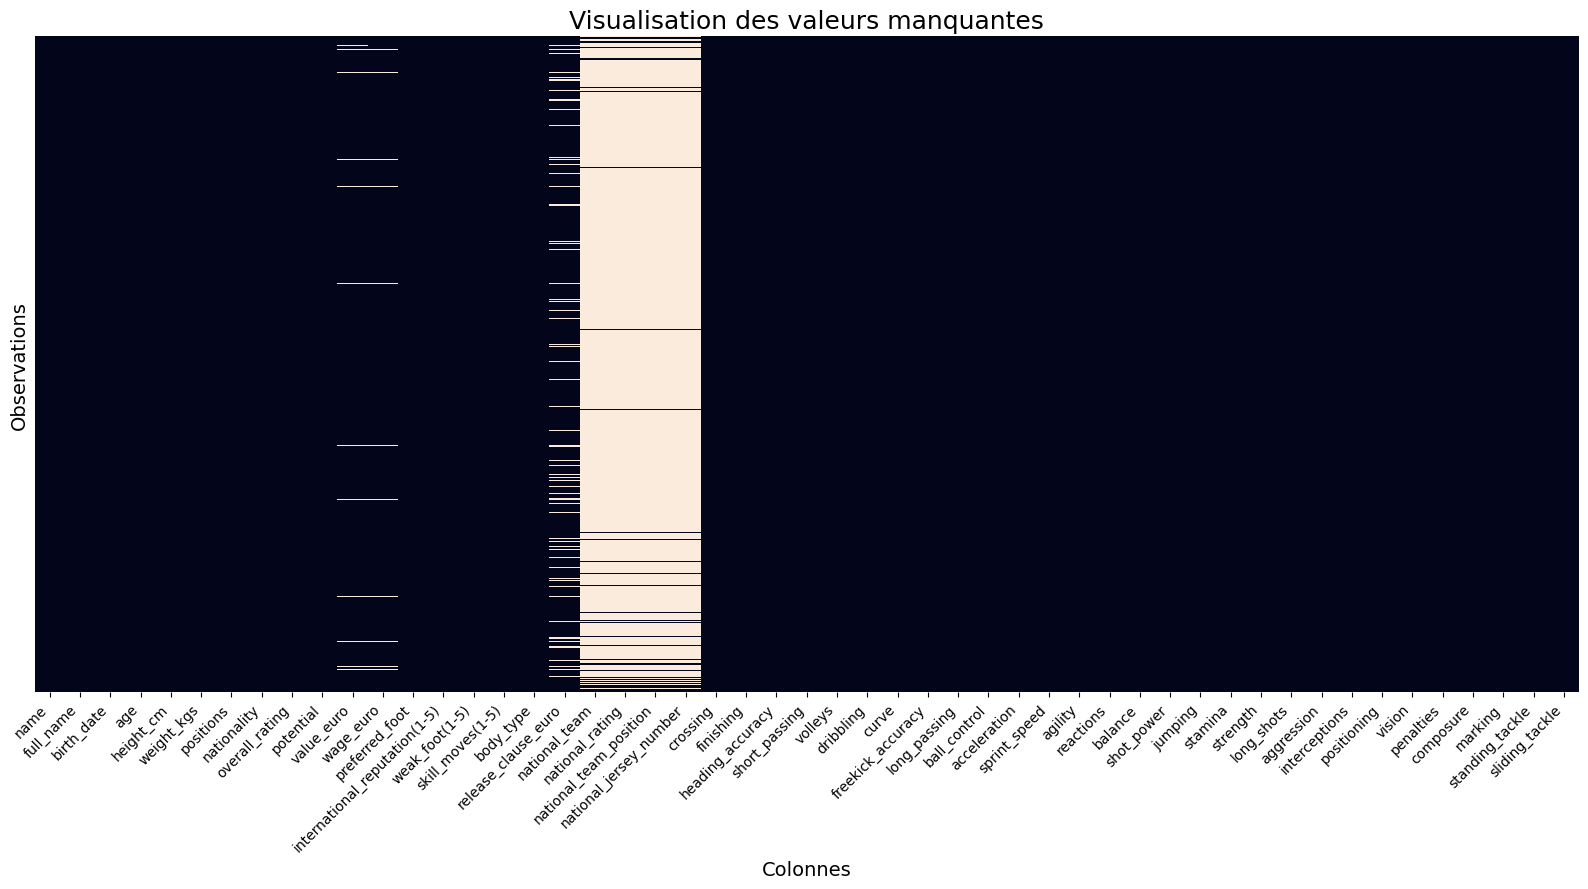

In [11]:
# Heatmap of missing values
plot_missing_values(df)


In [12]:
# Drop rows where 'value_euro' or 'wage_euro' is missing
df = df.dropna(subset=['value_euro', 'wage_euro'])
df.isnull().sum()


name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                           0
wage_euro                            0
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro               1582
national_team                    16842
national_rating                  16842
national_team_position           16842
national_jersey_number           16842
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

In [13]:
# Fill missing 'release_clause_euro' values with the median
df['release_clause_euro'].fillna(df['release_clause_euro'].median(), inplace=True)

# Check that no missing values remain in 'release_clause_euro'
print(df.isnull().sum())


name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                           0
wage_euro                            0
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro                  0
national_team                    16842
national_rating                  16842
national_team_position           16842
national_jersey_number           16842
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

C:\Users\natha\AppData\Local\Temp\ipykernel_18736\2041645752.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['release_clause_euro'].fillna(df['release_clause_euro'].median(), inplace=True)
C:\Users\natha\AppData\Local\Temp\ipykernel_18736\2041645752.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['release_clause_euro'].fillna(df[

In [14]:
# Columns to drop
cols_to_drop = ['national_team', 'national_rating', 'national_team_position', 'national_jersey_number']


# Drop only the columns that exist
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')


In [15]:
df.isnull().sum()

name                             0
full_name                        0
birth_date                       0
age                              0
height_cm                        0
weight_kgs                       0
positions                        0
nationality                      0
overall_rating                   0
potential                        0
value_euro                       0
wage_euro                        0
preferred_foot                   0
international_reputation(1-5)    0
weak_foot(1-5)                   0
skill_moves(1-5)                 0
body_type                        0
release_clause_euro              0
crossing                         0
finishing                        0
heading_accuracy                 0
short_passing                    0
volleys                          0
dribbling                        0
curve                            0
freekick_accuracy                0
long_passing                     0
ball_control                     0
acceleration        

In [16]:
# Drop the height_cm column because its values are inconsistent
df.drop(columns=['height_cm'], inplace=True, errors='ignore')

In [17]:
# Missing values after preprocessing
df.isnull().sum()

name                             0
full_name                        0
birth_date                       0
age                              0
weight_kgs                       0
positions                        0
nationality                      0
overall_rating                   0
potential                        0
value_euro                       0
wage_euro                        0
preferred_foot                   0
international_reputation(1-5)    0
weak_foot(1-5)                   0
skill_moves(1-5)                 0
body_type                        0
release_clause_euro              0
crossing                         0
finishing                        0
heading_accuracy                 0
short_passing                    0
volleys                          0
dribbling                        0
curve                            0
freekick_accuracy                0
long_passing                     0
ball_control                     0
acceleration                     0
sprint_speed        

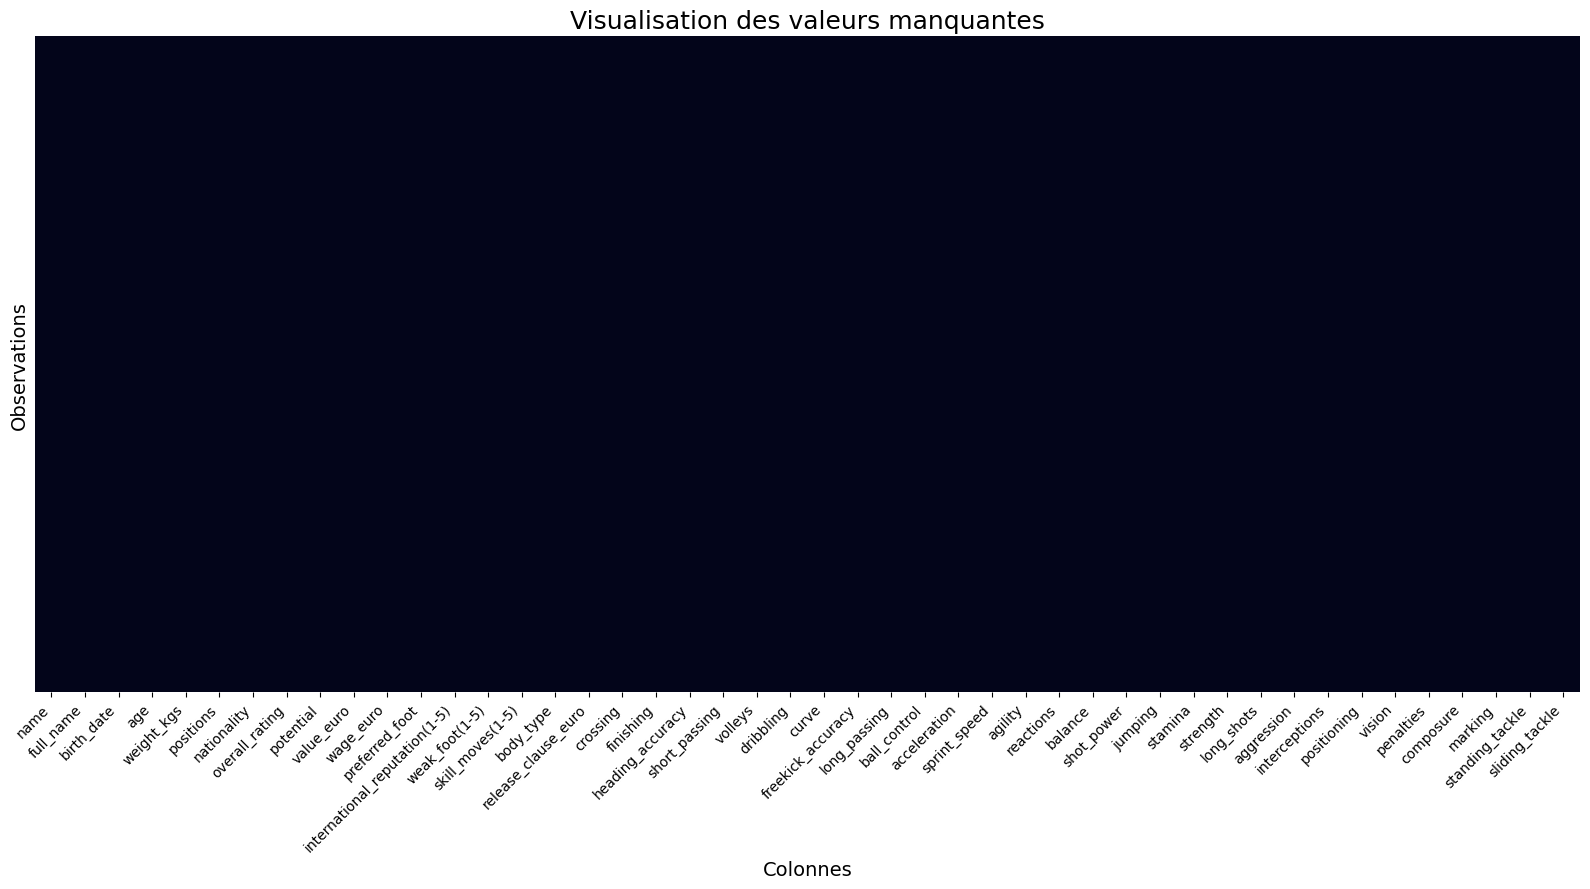

In [18]:
# Heatmap of missing values after preprocessing
plot_missing_values(df)


#### No missing values remain after preprocessing: the data are clean and ready for analysis.

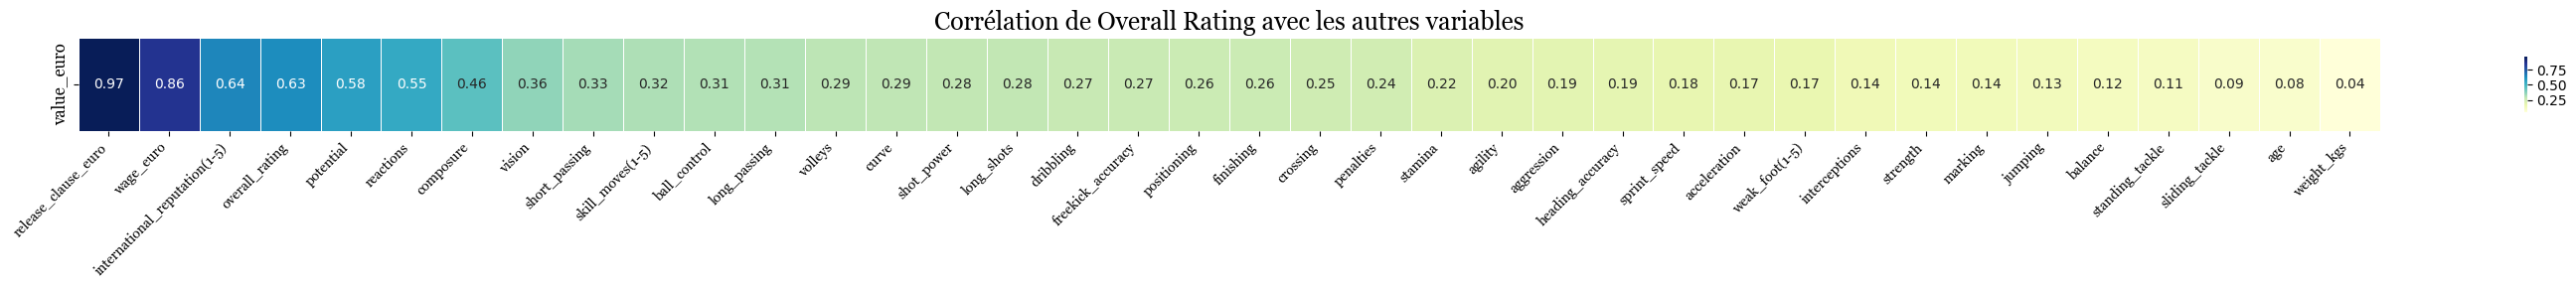

In [19]:
# 1. Select the numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# 2. Compute the correlation matrix
correlation_matrix = df_numeric.corr()

# 3. Keep only the 'value_euro' row and sort it
overall_corr = correlation_matrix.loc[["value_euro"]].drop(columns=["value_euro"])
overall_corr = overall_corr.reindex(overall_corr.T.abs().sort_values(by="value_euro", ascending=False).index, axis=1)

# 4. Display: wide horizontal heatmap
plt.figure(figsize=(30, 3))  # Wide figure for the horizontal layout

sns.heatmap(overall_corr,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            linewidths=0.5,
            cbar_kws={"shrink": .6})

plt.title("Corrélation de Overall Rating avec les autres variables", fontsize=18, fontname="Georgia")
plt.xticks(rotation=45, ha='right', fontsize=10, fontname="Georgia")
plt.yticks(fontsize=12, fontname="Georgia")
plt.tight_layout()
plt.show()


#### The correlation matrix highlights the relationships between the numeric variables of the dataset, in particular the strong correlation between the overall rating (overall_rating) and several technical and mental attributes such as ball control, vision, composure and reactions. This correlation, also very marked with market value (value_euro), justifies focusing first on the impact of the overall rating on player valuation. This indicator was chosen because it summarises individual performance, and therefore reflects the economic interest a player can attract. The impact of position on market value, although not directly observable in the matrix (since position is categorical), makes it possible to explore differences in valuation by role on the pitch, some positions being historically more sought after. The study of birth month aims to check whether the relative age effect, well documented in training, still influences the value of professional players. Finally, the analysis by nationality helps to understand the differences linked to the sporting, economic and structural environment of countries, showing that a player's value also depends on the context in which they play. These objectives are complementary and aim to give a detailed understanding of the factors influencing market value in professional football.

# Market Value by Nationality

In [21]:
import plotly.graph_objs as go
import plotly.express as px
import webbrowser

In [22]:
# Map the UK constituent countries to "United Kingdom"
uk_countries = ["England", "Scotland", "Wales", "Northern Ireland"]
df["nationality"] = df["nationality"].replace(uk_countries, "United Kingdom")


In [23]:
# Average market value per country
# Drop rows with missing values to avoid errors
df = df.dropna(subset=["value_euro", "nationality"])

# Compute the average market value per country
df_value = df.groupby('nationality', as_index=False)['value_euro'].mean()



fig3d = go.Figure(data=go.Choropleth(
    locations=df_value["nationality"],  # Match countries by name
    locationmode="country names",  # Location mode: country names
    z=df_value["value_euro"],  # Average market value of players
    colorscale=GREEN_SCALE,
    colorbar_title="Valeur marchande (€)",
))


fig3d.update_layout(
    geo=dict(
        showcoastlines=True,
        coastlinecolor="Black",
        projection_type="natural earth",
        projection_scale=3.0,  
    ),
    title="Valeur marchande moyenne des joueurs par pays - Carte 3D",
    scene=dict(
        xaxis_title="Longitude",
        yaxis_title="Latitude",
        zaxis_title="Valeur marchande (€)",
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
)

# Generate and open the map
fig3d.write_html("valeur_marchande_carte_3d.html")
webbrowser.open("valeur_marchande_carte_3d.html")


True

#### This script creates an interactive map showing the average market value of players per country. After cleaning the data, it computes the average per nationality, then uses Plotly to generate a choropleth map coloured by value, projected onto a world map of the "natural earth" type and opened as HTML. The first chart shows that countries with a strong football tradition (France, United Kingdom, Germany, Brazil, Spain) have high values, thanks to solid infrastructure, a deep-rooted football culture and substantial investment. Conversely, countries with fewer resources or less recognition show lower values, revealing disparities in training and investment in football.

In [619]:
# Number of players per country
df_players = df["nationality"].value_counts().reset_index()
df_players.columns = ["nationality", "count"]

# Build the map of player counts per country
fig3d = go.Figure(data=go.Choropleth(
    z=df_players["count"],  # Values to colour (number of players)
    hoverinfo="location+z",  # Show country and value on hover
    locations=df_players["nationality"],  # Match countries by name
    locationmode="country names",  # Location mode: country names
    colorbar_title="Nombre de joueurs",
    colorscale=GREEN_SCALE,
))

# Update the figure layout
fig3d.update_layout(
    geo=dict(
        showcoastlines=True,
        coastlinecolor="Black",
        projection_type="natural earth",
        projection_scale=3.0,  # Zoom in slightly for a better view of the map
    ),
    title="Nombre de joueurs par pays - Carte 3D",
    scene=dict(
        xaxis_title="Longitude",
        yaxis_title="Latitude",
        zaxis_title="Nombre de joueurs",
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
)

fig3d.write_html("nombre_joueurs_carte_3d.html")
webbrowser.open("nombre_joueurs_carte_3d.html")


True

#### This script generates an interactive choropleth map showing how players are distributed by country, by counting them per nationality. Although described as "3D", the map relies on an enhanced 2D projection, with a green colour scale indicating the number of players, and is exported as HTML for viewing in the browser. A second chart shows the average market value per country, revealing that some countries, despite a limited number of players, have high averages, often due to the presence of exceptional talent. This valuation is influenced by the prestige of national leagues, the reputation of clubs, and economic factors such as the strength of the local currency. Together, these visualisations show that the average value depends not only on the number of players, but also on their individual quality and on the economic and sporting context in which they play.

In [620]:
# Definition of the geographic regions
regions = {
    "Amérique Latine": [
        "Argentina", "Brazil", "Uruguay", "Chile", "Paraguay", "Peru", "Ecuador",
        "Colombia", "Venezuela", "Bolivia", "Costa Rica"
    ],
    "Amérique du Nord": [
        "United States", "Canada", "Mexico", "Cuba", "Panama", "Haiti", "Dominican Republic",
        "Nicaragua", "Guatemala", "El Salvador", "Honduras"
    ],
    "Europe de l'Ouest": [
        "France", "Germany", "United Kingdom", "Spain", "Italy", "Netherlands", "Belgium",
        "Switzerland", "Austria", "Portugal", "Ireland", "Luxembourg", "Republic of Ireland",
        "Andorra", "Malta", "Liechtenstein"
    ],
    "Europe de l'Est": [
        "Poland", "Czech Republic", "Slovakia", "Hungary", "Romania", "Bulgaria",
        "Ukraine", "Belarus", "Russia", "Moldova", "Armenia", "Georgia", "Azerbaijan"
    ],
    "Europe du Nord": [
        "Denmark", "Sweden", "Norway", "Finland", "Iceland", "Estonia", "Latvia", "Lithuania",
        "Faroe Islands"
    ],
    "Balkans": [
        "Serbia", "Croatia", "Bosnia Herzegovina", "Montenegro", "Slovenia", "Albania", "Kosovo",
        "FYR Macedonia", "Greece", "Cyprus"
    ],
    "Afrique du Nord": [
        "Egypt", "Morocco", "Algeria", "Tunisia", "Libya", "Mauritania"
    ],
    "Afrique de l'Ouest": [
        "Senegal", "Ivory Coast", "Ghana", "Nigeria", "Mali", "Burkina Faso", "Togo", "Benin",
        "Guinea", "Guinea Bissau", "Liberia", "Sierra Leone", "Gambia", "Cape Verde"
    ],
    "Afrique Centrale": [
        "Cameroon", "DR Congo", "Congo", "Gabon", "Equatorial Guinea", "Central African Rep.",
        "Chad", "Angola", "São Tomé & Príncipe"
    ],
    "Afrique de l'Est": [
        "Kenya", "Tanzania", "Uganda", "Ethiopia", "Eritrea", "Rwanda", "Burundi", "Sudan",
        "South Sudan", "Mozambique", "Madagascar", "Comoros"
    ],
    "Afrique Australe": [
        "South Africa", "Zambia", "Zimbabwe", "Namibia"
    ],
    "Moyen-Orient": [
        "Saudi Arabia", "Iran", "Iraq", "Israel", "Palestine", "Jordan", "United Arab Emirates",
        "Qatar", "Oman", "Kuwait", "Syria", "Lebanon", "Yemen", "Turkey", "Afghanistan"
    ],
    "Asie de l'Est": [
        "China PR", "Japan", "South Korea", "North Korea", "Mongolia", "Hong Kong", "Macau", "Taiwan",
        "Korea Republic", "Korea DPR"
    ],
    "Asie du Sud": [
        "India", "Pakistan", "Bangladesh", "Sri Lanka", "Nepal", "Bhutan", "Maldives", "Uzbekistan", "Kazakhstan"
    ],
    "Asie du Sud-Est": [
        "Thailand", "Indonesia", "Philippines", "Vietnam"
    ],
    "Océanie": [
        "Australia", "New Zealand", "Fiji", "Papua New Guinea", "New Caledonia", "Guam", "Montserrat"
    ],
    "Caraïbes & Petits États": [
        "Bermuda", "Grenada", "St Kitts Nevis", "Antigua & Barbuda", "Barbados",
        "St Lucia", "Trinidad & Tobago", "Guyana", "Suriname", "Curacao",'Jamaica'
    ]
}


# Return the region of a country
def get_region(country):
    for region, countries in regions.items():
        if country in countries:
            return region
    return "Autres"  # Countries not listed fall back to "Autres" (only used for testing)

# Apply the function to create a 'region' column
df["region"] = df["nationality"].apply(get_region)



# Count players per region
df_region_count = df["region"].value_counts().reset_index()
df_region_count.columns = ["region", "num_players"]

# Compute the average market value per region
df_avg_region = df.groupby("region", as_index=False)["value_euro"].mean()

# Merge the two tables
df_region_stats = df_avg_region.merge(df_region_count, on="region")


# Scatter plot with outlines and labels
fig = px.scatter(df_region_stats,
                 x="num_players",
                 y="value_euro",
                 size=df_region_stats["num_players"],  # Size proportional to the number of players
                 color="value_euro",
                 color_continuous_scale=GREEN_SCALE,
                 title="Relation entre le nombre de joueurs et la valeur marchande moyenne par région",
                 labels={"num_players": "Nombre de joueurs", "value_euro": "Valeur marchande moyenne (€)"},
                 hover_name="region",
                 text=df_region_stats["region"],  # Add region labels
                 size_max=100)  # Increase the maximum circle size

# Black outline around the circles
fig.update_traces(marker=dict(line=dict(width=2, color='black')))

# Label position
fig.update_traces(textposition='top center')

# Logarithmic x-axis
fig.update_layout(xaxis_type="log")

# Save and open the chart
fig.write_html("scatter_valeur_region.html")
webbrowser.open("scatter_valeur_region.html")


True

#### This bubble chart shows the relationship between the **number of players** and the **average market value** per world region. The script starts by grouping countries into large geographic regions, then assigns each player to a region based on their nationality. For each region it computes the total number of players and the average of their market value. The chart displays these data as bubbles: the horizontal (logarithmic) axis shows the number of players, the vertical axis the average market value (€), bubble size is proportional to the number of players, and colour indicates market value. This visualisation makes it easy to see which regions produce the most players and where the average value is highest.

The analysis of the three charts shows that players' market value is closely linked to nationality. This link reflects cultural and socio-economic factors and sports infrastructure, as well as the prestige of leagues and clubs. The quality of training, economic support and the competitiveness of local championships all play a crucial role in how talent is valued on the transfer market.

## Influence of overall_rating on market value

In [23]:
import plotly.express as px 
import webbrowser
from scipy.stats import pearsonr

# Data cleaning
df["overall_rating"] = df["overall_rating"].fillna(df["overall_rating"].median())
df["value_euro"] = df["value_euro"].fillna(0)
df["full_name"] = df["full_name"].fillna("Joueur Inconnu")
df["color_variation"] = df["age"].fillna(df["age"].median()) + np.random.uniform(-1.5, 1.5, df.shape[0])

# Pearson correlation
corr_coef, _ = pearsonr(df["overall_rating"], df["value_euro"])
corr_text = f"Corrélation (Pearson) : {corr_coef:.2f}"

# Scatter plot
fig = px.scatter(df, x="overall_rating", y="value_euro", 
                 size="value_euro", color="color_variation",  
                 title="Corrélation entre Overall Rating et Valeur (€) - Tous les Joueurs",
                 labels={"overall_rating": " Note Globale (Overall Rating)", 
                         "value_euro": "Valeur (€)", 
                         "color_variation": " Âge Ajusté"},
                 hover_name="full_name",
                 color_continuous_scale="Turbo",
                 template="plotly_white",
                 opacity=0.85,
                 size_max=45)

# General style
fig.update_layout(
    title_font=dict(size=26, color="black", family="Georgia"),
    xaxis=dict(title_font=dict(size=20, family="Georgia"), showgrid=True, gridcolor="lightgray"),
    yaxis=dict(title_font=dict(size=20, family="Georgia"), showgrid=True, gridcolor="lightgray"),
    coloraxis_colorbar=dict(title="Âge des Joueurs", title_font=dict(size=18, family="Georgia"))
)

# Annotation placed in the visible area (e.g. x=60, y=90_000_000)
fig.add_annotation(
    x=60,
    y=90_000_000,
    text=corr_text,
    showarrow=False,
    font=dict(size=30, family="Georgia", color="black"),
    align="left",
    bgcolor="rgba(255,255,255,0.8)",
    bordercolor="black",
    borderwidth=1
)

# Export an interactive HTML file and open it
html_file_path = "scatter_overall_value_annotated.html"
fig.write_html(html_file_path)
webbrowser.open(html_file_path)


True

#### This scatter plot highlights the **correlation between players' overall rating (Overall Rating)** and their **market value (€)**. To provide a complete representation, missing values were replaced by default values (median or 0). Each point represents a player, with its size proportional to market value and its colour linked to age (slightly randomly adjusted for better visual distinction). The chart uses the *Turbo* palette for more visual impact, and interactivity lets users display the player's full name on hover. This visualisation makes it possible to detect overall trends and exceptional players, while offering a smooth and attractive reading.

In [622]:
import plotly.graph_objects as go
import webbrowser

# Attributes to display for each player
players_data = {
    "L. Messi": {
        "attributes": ["finishing", "positioning", "heading_accuracy", "reactions",
                       "shot_power", "ball_control", "dribbling", "volleys",
                       "long_shots", "acceleration", "sprint_speed", "strength"],
        "title": " Lionel Messi - Meilleur Attaquant (ST)",
        "color": "#FF5733"
    },
    "K. De Bruyne": {
        "attributes": ["short_passing", "long_passing", "vision", "ball_control",
                       "dribbling", "positioning", "interceptions", "reactions",
                       "standing_tackle", "stamina", "long_shots"],
        "title": " Kevin De Bruyne - Meilleur Milieu de terrain (CM)",
        "color": "#1E90FF"
    },
    "Sergio Ramos": {
        "attributes": ["marking", "sliding_tackle", "standing_tackle", "heading_accuracy",
                       "strength", "aggression", "interceptions", "short_passing",
                       "reactions", "ball_control", "jumping"],
        "title": " Sergio Ramos - Meilleur Défenseur Central (CB)",
        "color": "#008000"
    }
}

# Build one radar chart per player
figures = []

for player, data in players_data.items():
    attributes = data["attributes"]
    color = data["color"]
    title = data["title"]

    # Keep only the attributes that exist in the data
    fifa_columns = df.columns.str.lower()
    filtered_columns = [col for col in attributes if col in fifa_columns]

    # Extract the player's attribute values
    player_data = df[df["name"] == player][filtered_columns].iloc[0]

    # Radar chart
    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=player_data.values,  # Attribute values
        theta=filtered_columns,  # Attribute names
        fill='toself',
        name=player,
        line=dict(color=color, width=3),
        marker=dict(size=10, color=color),
        opacity=0.8
    ))

    # Radar chart styling
    fig.update_layout(
        polar=dict(
            bgcolor="#f5f5f5",
            radialaxis=dict(
                visible=True,
                range=[0, 100],
                gridcolor="lightgray",
                linecolor="gray"
            ),
            angularaxis=dict(
                tickfont=dict(family="Georgia", size=14, color="black")
            )
        ),
        title=dict(
            text=title,
            font=dict(family="Georgia", size=22, color="black"),
            x=0.5
        ),
        font=dict(family="Georgia", size=14, color="black"),
        showlegend=True
    )

    figures.append(fig)

# Combine the radar charts into one HTML file laid out as a grid
html_file_path = "radars_messi_debruyne_ramos.html"
with open(html_file_path, "w") as f:
    f.write("""
    <html>
    <head>
        <title>Radars - Messi, De Bruyne & Ramos</title>
        <style>
            body { font-family: Georgia, serif; text-align: center; background-color: #f9f9f9; }
            .grid-container {
                display: grid;
                grid-template-columns: 1fr 1fr;
                gap: 20px;
                justify-items: center;
                margin: 40px;
            }
            .full-width {
                grid-column: span 2;
                margin-top: 20px;
            }
        </style>
    </head>
    <body>
        <h1>Comparaison des Profils Joueurs</h1>
        <div class='grid-container'>
    """)

    # Add the first two radars side by side
    f.write("<div>" + figures[0].to_html(full_html=False, include_plotlyjs="cdn") + "</div>")
    f.write("<div>" + figures[1].to_html(full_html=False, include_plotlyjs="cdn") + "</div>")

    # Add the last radar full width at the bottom
    f.write("<div class='full-width'>" + figures[2].to_html(full_html=False, include_plotlyjs="cdn") + "</div>")

    f.write("""
        </div>
    </body>
    </html>
    """)

# Open the HTML file in the browser automatically
print(f"Fichier HTML interactif généré : '{html_file_path}'. Ouverture en cours...")
webbrowser.open(html_file_path)


Fichier HTML interactif généré : 'radars_messi_debruyne_ramos.html'. Ouverture en cours...


True

#### This code generates interactive radar charts to compare specific attributes of three football players: Lionel Messi, Kevin De Bruyne and Sergio Ramos. For each one, a custom selection of statistics (e.g. dribbling, passing, tackling) is extracted from a DataFrame and displayed as a radar chart with a distinct visual style (colour, typography, layout). The three radars are then combined in a single HTML file arranged in a grid.

# Impact of Player Position on Market Value

In [4]:
import networkx as nx
from matplotlib.patches import Rectangle
from mplsoccer import VerticalPitch
from matplotlib import cm
from matplotlib import patheffects

Position,Nombre
CB,3038
ST,2482
CM,2128
GK,2024
CDM,1361
RB,1322
LB,1309
RM,1045
CAM,1027
LM,1017


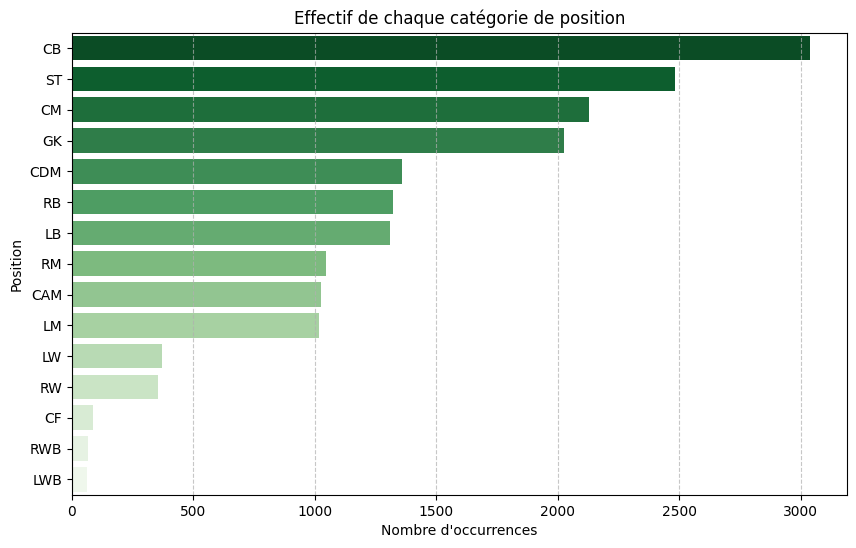

In [26]:

# Build the table of counts
res = df["positions"].str.split(',').str[0]
value_counts = res.value_counts().reset_index()

# Rename the columns
value_counts.columns = ['Position', 'Nombre']

# Style the table and hide the index
styled_table = value_counts.style.set_table_attributes('class="table table-striped"') \
    .hide(axis="index")

# Display the position table
display(styled_table)

# Bar chart of the position counts
plot_count_bars(value_counts, 'Position', 'Position')


#### The table shows the number of players listed for each position on the pitch, using standard abbreviations such as CB for Central Back (centre-back), ST for Striker (attacker) and GK for Goalkeeper. The analysis of these data reveals an uneven distribution of players across positions, with some positions noticeably over-represented compared with others.

#### Centre-backs (CB) form the largest group, with 3,038 players, which is explained by the fact that most professional teams generally field several centre-backs in their basic formations. Strikers (ST) also form a sizeable group with 2,482 players, underlining the importance of this position in squads. Central midfielders (CM) and goalkeepers (GK) are also well represented, with 2,128 and 2,024 players respectively, which is logical given their key role in a team's structure.

#### By contrast, some specific positions are much less common. For example, support strikers (CF), right wing-backs (RWB) and left wing-backs (LWB) each have fewer than 100 players. This can be explained by their more occasional use in modern tactical systems, where these roles are often adapted to the team's strategy.

In [625]:

# Keep the first listed position
res = df["positions"].str.split(',').str[0]

# Keep players whose first position is RM or LM
filtered_players = df[res.isin(['RM', 'LM'])]

# Display the last 10 matching players
styled_filtered_players = filtered_players[['name']].tail(10).style.set_table_attributes('class="table table-striped"') \
    .set_caption("Joueurs RM/LM") \
    .hide(axis="index")

# Display the styled RM/LM table
display(styled_filtered_players)


name
Quaresma
J. Cuadrado
Felipe Anderson
F. Thauvin
I. Perišić
Y. Brahimi
Douglas Costa
Koke
H. Son
R. McKenzie


#### We chose to classify LM (Left Mid) and RM (Right Mid) positions in the "Attacker" category rather than "Midfielder". This decision rests on the fact that, in practice, players in these positions are often attacking wingers, whose role is closer to that of an attacker than to a classic central midfielder. In modern football, these positions are generally occupied by players whose main attributes are pace, dribbling and the ability to create goal-scoring chances, which justifies moving them into this category.

#### Furthermore, looking at players often classified as LM or RM, such as Douglas Costa or Florian Thauvin, who mainly played in an offensive role rather than as link midfielders, it seemed more sensible to treat them as attackers.

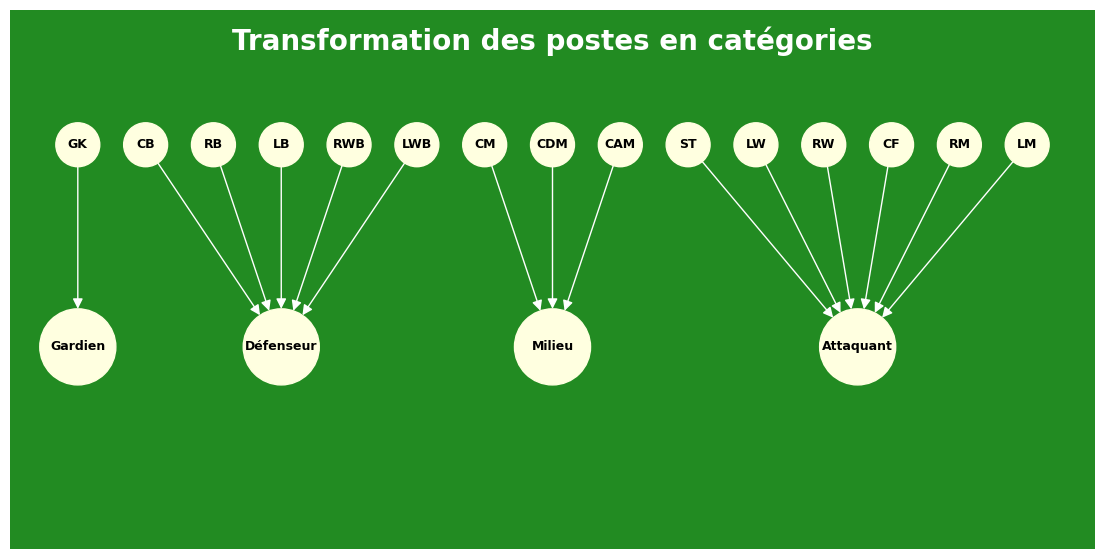

In [626]:
# Build the graph
G = nx.DiGraph()

# Add the edges (position -> category)
for position, category in position_to_category.items():
    G.add_edge(position, category)

# Manual layout
positions = list(position_to_category.keys())
categories = ["Gardien", "Défenseur", "Milieu", "Attaquant"]
pos = {}

# Place the positions on the first row
for i, position in enumerate(positions):
    pos[position] = (i * 2, 1)

# Centre each category above its positions
for category in categories:
    related_positions = [pos[position][0] for position, cat in position_to_category.items() if cat == category]
    pos[category] = (np.mean(related_positions), -0.5)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(14, 7))

# Green background
ax.add_patch(Rectangle((-10, -10), 100, 20, color="#228B22", zorder=-1))

# Node sizes: positions vs categories
node_sizes = {node: 3000 if node in categories else 1000 for node in G.nodes()}

# Draw the graph
nx.draw(G, pos, with_labels=True, node_color="lightyellow", edge_color="white",
        node_size=[node_sizes[node] for node in G.nodes()],
        font_size=9, font_weight="bold", arrows=True, arrowsize=15, ax=ax)

# Title, centred above the graph
plt.text(np.mean([pos[node][0] for node in positions]), 1.7, 
         "Transformation des postes en catégories", 
         fontsize=20, fontweight='bold', color="white", ha='center')

plt.xlim(-2, 30)
plt.ylim(-2, 2)
plt.axis("off")
plt.show()

#### To simplify the analysis of the impact of position on market value, players' individual positions were grouped into four main categories: Defender, Midfielder, Attacker and Goalkeeper. This classification makes it easier to compare the different positions according to their overall role on the pitch. The specific positions were grouped as follows:
#### Defender: CB, RB, LB, RWB, LWB
#### Midfielder: CM, CDM, CAM
#### Attacker: ST, LW, RW, CF, RM, LM
#### Goalkeeper: GK

#### Defenders are the largest group with 5,801 players, followed by attackers (5,358 players) and midfielders (4,516 players). Goalkeepers are naturally less numerous, with only 2,024 players, which is expected since a team usually has only one starting goalkeeper.

Categorie,Nombre
Défenseur,5801
Attaquant,5358
Milieu,4516
Gardien,2024


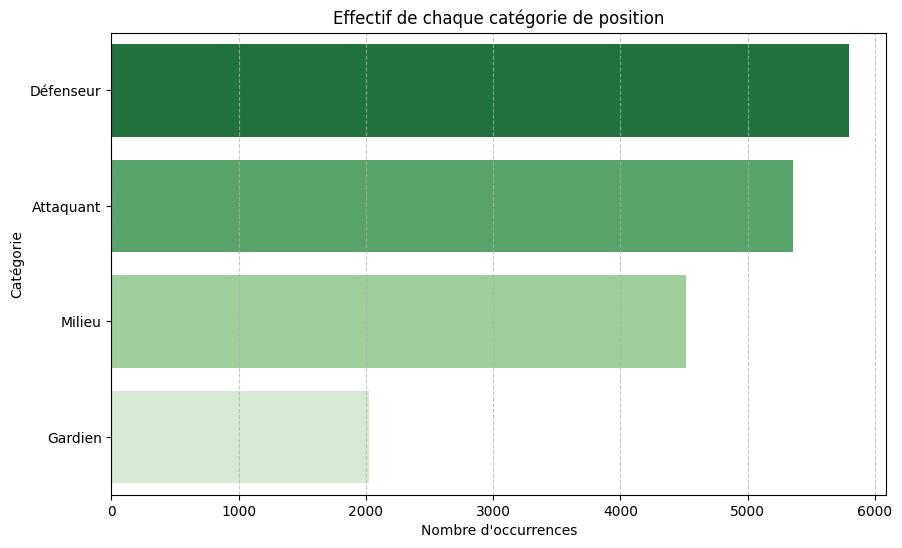

In [29]:
# Mapping from position to category
position_to_category = {
    # Goalkeepers
    "GK": "Gardien",
    
    # Defenders
    "CB": "Défenseur", "RB": "Défenseur", "LB": "Défenseur",
    "RWB": "Défenseur", "LWB": "Défenseur",
    
    # Midfielders
    "CM": "Milieu", "CDM": "Milieu", "CAM": "Milieu",
    
    # Attackers
    "ST": "Attaquant", "LW": "Attaquant", "RW": "Attaquant",
    "CF": "Attaquant",
    "RM": "Attaquant", "LM": "Attaquant"
}

# Map each position to its category
df["positions"] = df["positions"].str.split(',').str[0].map(position_to_category)

# Build the table of category counts
position_category_counts = df["positions"].value_counts().reset_index()
position_category_counts.columns = ['Categorie', 'Nombre']

# Style the table and hide the index
styled_category_table = position_category_counts.style.set_table_attributes('class="table table-striped"') \
    .hide(axis="index")

# Display the category table
display(styled_category_table)

plot_count_bars(position_category_counts, "Categorie", "Catégorie")


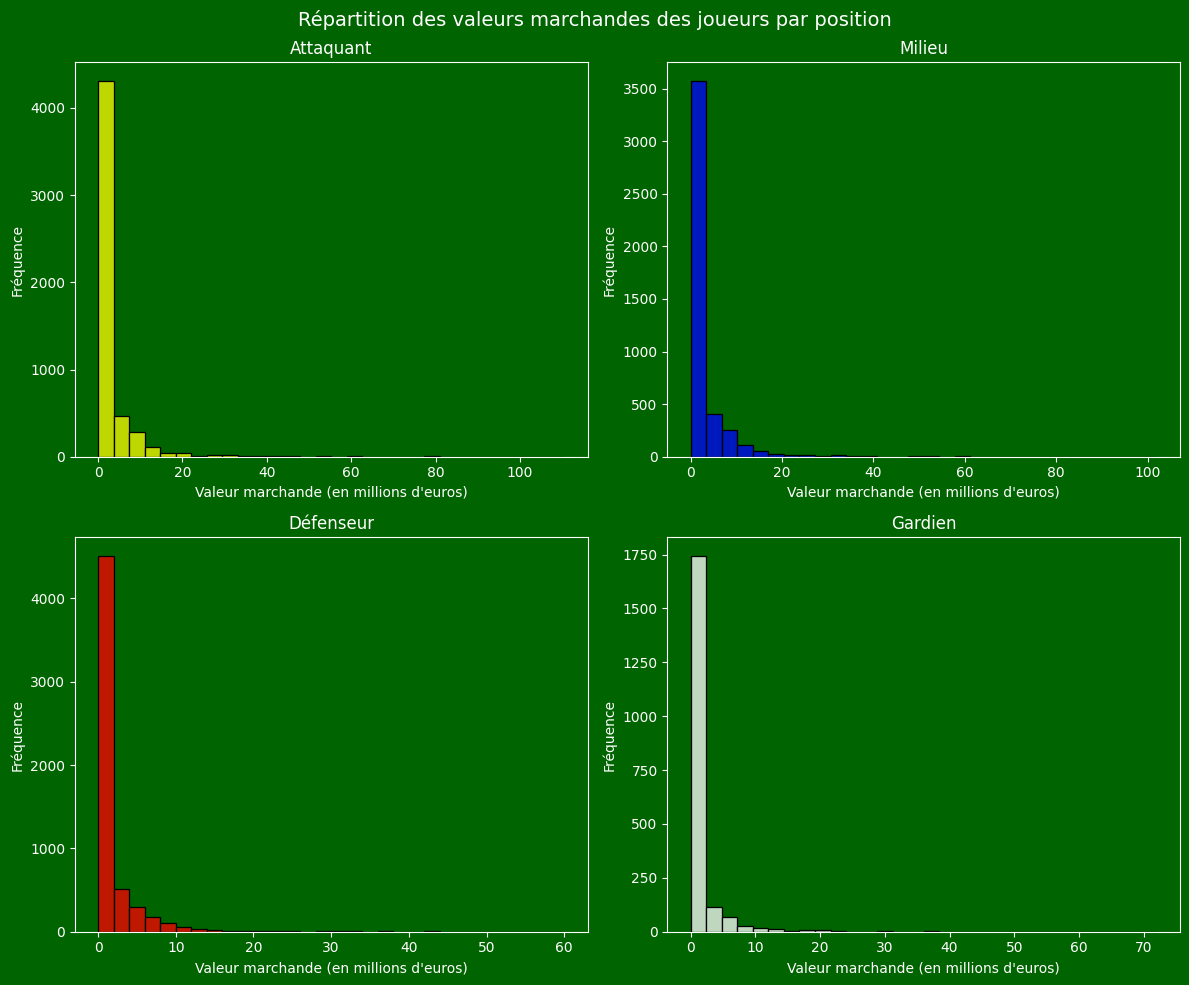

In [30]:
# Unique categories
positions = df['positions'].unique()

# Football-inspired colour palette
colors = ['yellow', 'blue', 'red', 'white']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten the grid

# Style
for i, pos in enumerate(positions):
    ax = axes[i]
    subset = df[df['positions'] == pos]  # Rows for this position

    # Histogram in the category colour
    sns.histplot(subset['value_euro'] / 1e6, bins=30, ax=ax, color=colors[i % len(colors)])

    # Design: green pitch background
    ax.set_facecolor('darkgreen')  # Green pitch
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(colors='white')

    ax.set_title(f'{pos}')
    ax.set_xlabel('Valeur marchande (en millions d\'euros)')
    ax.set_ylabel('Fréquence')

# Figure title
fig.suptitle("Répartition des valeurs marchandes des joueurs par position", color='white', fontsize=14)

# Adjust the layout and figure background
plt.tight_layout()
fig.patch.set_facecolor('darkgreen')

# Display the figure
plt.show()


#### The analysis of the distributions of market values by position reveals a common trend: for each position, many players have a market value concentrated within a certain range, while very high values are rarer. This shows that although some players reach exceptional amounts, most fall within more accessible ranges.

#### However, differences appear between positions. Attackers and midfielders generally have higher market values than defenders and goalkeepers (see the market value scale), with peaks above 100 million euros for some attackers and around 80 million euros for midfielders. By comparison, defenders rarely exceed 50 million euros, while goalkeepers have even lower values, rarely exceeding 30 to 40 million euros. Despite these variations, the overall distribution follows a similar pattern for each position, marked by a rapid decline in frequency as market value increases.

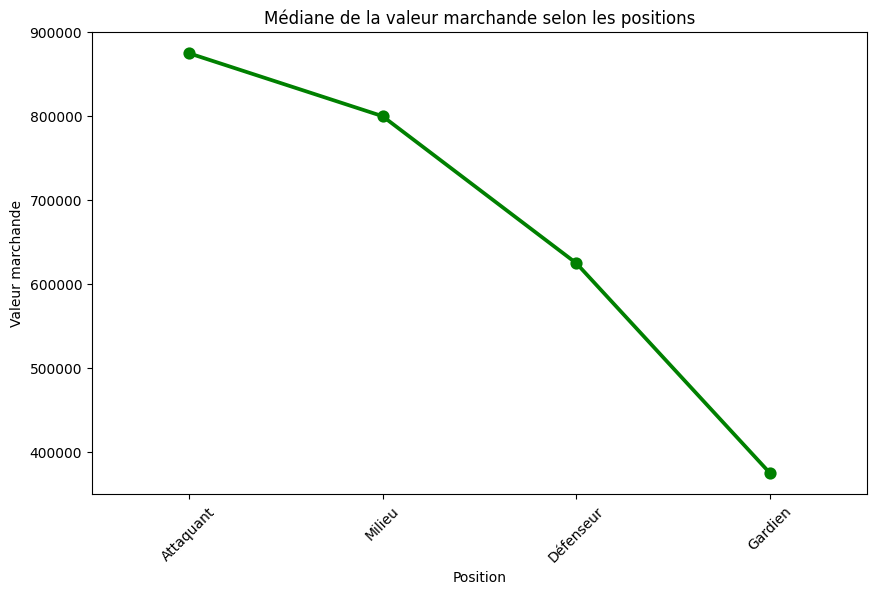

In [629]:
plt.figure(figsize=(10, 6))
sns.pointplot(x='positions', y='value_euro', data=df, estimator=np.median, errorbar=None,color='green')
plt.title('Médiane de la valeur marchande selon les positions')
plt.xlabel('Position')
plt.ylabel('Valeur marchande')
plt.xticks(rotation=45)
plt.show()

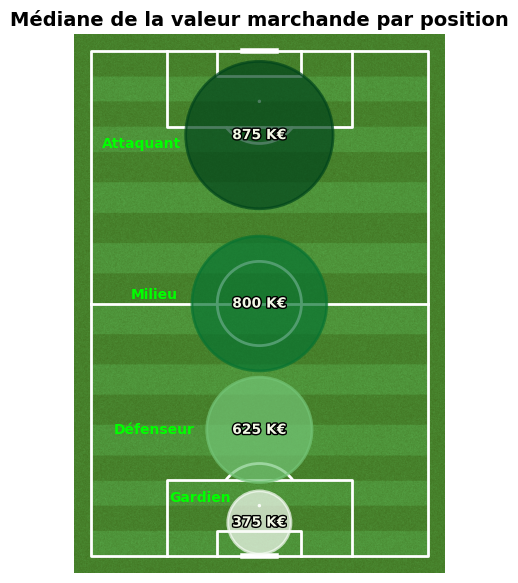

In [630]:
# Median of 'value_euro' per position
moyennes = df.groupby('positions')['value_euro'].median() / 1e3  # Median in thousands of euros (K€)

# Circle positions on the pitch (x, y)
positions_coords = {
    'Gardien': (8, 40),
    'Défenseur': (30, 40),
    'Milieu': (60, 40),
    'Attaquant': (100, 40)
}

# Manual label coordinates
label_coords = {
    'Gardien': (26, 14),      # Slightly higher
    'Défenseur': (15, 30),   # Slightly higher
    'Milieu': (15, 62),      # Slightly higher
    'Attaquant': (12, 98)   # Slightly higher
}

# Draw the football pitch
fig, ax = plt.subplots(figsize=(10, 7))
pitch = VerticalPitch(pitch_color='grass', line_color='white', stripe=True)
pitch.draw(ax=ax)

# Colour map from light to dark green
cmap = cm.Greens  # Green colormap
norm = plt.Normalize(vmin=moyennes.min(), vmax=moyennes.max())  # Normalise values for the colormap

# Draw circles proportional to the median of each position
for pos, (x, y) in positions_coords.items():
    if pos in moyennes:
        value = moyennes[pos]  # Median for this position
        size = value * 60  # Circle size
        color = cmap(norm(value))  # Colour according to the value
        
        # Circle with fill and border
        circle = plt.Circle((y, x), size / 3000, color=color, alpha=0.7, edgecolor='black', lw=2)
        ax.add_patch(circle)
        
        # Light text with a dark outline for contrast
        text = plt.text(y, x, f'{value:.0f} K€', ha='center', va='center', fontsize=10, color='#f2f9e6', fontweight='bold')
        text.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])


# Add the position labels at their manual coordinates
for pos, (x_label, y_label) in label_coords.items():
    plt.text(x_label, y_label, pos, ha='center', va='center', fontsize=10, color='#00FF00', fontweight='bold')

# Title and display
plt.title('Médiane de la valeur marchande par position', fontsize=14, fontweight='bold')
plt.show()

#### The chart shows that the median market value varies considerably with the position players occupy. The median was preferred to the mean in order to limit the influence of extreme values, which can distort the analysis because of a few exceptionally expensive players. It better reflects the central tendency of the market for each position, giving a more realistic picture of market values.

#### Attackers have the highest median value, above 880,000, which reflects their often decisive role and strong demand on the market. Midfielders follow, with a slightly lower median value of around 800,000. Defenders show a more marked decline, with a median of around 630,000, while goalkeepers have the lowest value, around 380,000. This hierarchy suggests that the most offensive positions are generally the most valued, probably because of their direct impact on the scoreline and their media visibility, whereas more defensive positions are valued less on the market.

#### These significant gaps show that the position a player occupies strongly influences their market value. The marked differences between attackers and goalkeepers underline the importance given to offensive positions, often seen as more decisive for a team's performance. This trend reflects the dynamics of the football market, where demand and perceived impact play a key role in how players are assessed.

# Market Value by Birth Month

## Objective

The objective of this analysis is to answer the following question:
**Does the birth month of a professional player influence their market value?**

This question is set in the context of the **Relative Age Effect (RAE)**, a phenomenon whereby players born early in the year are often favoured in sports selection from a young age, notably because of an advantage in physical maturity.

Before analysing market value, we first look at the **distribution of birth dates** among professional players. The first chart below therefore shows the **number of professional players per birth month**.


In [631]:
# Convert birth_date to datetime format
df["birth_date"] = pd.to_datetime(df["birth_date"], errors="coerce")

# Extract birth month
df["birth_month"] = df["birth_date"].dt.month

colors = plt.cm.Greens(np.linspace(0.4, 0.8, 4))

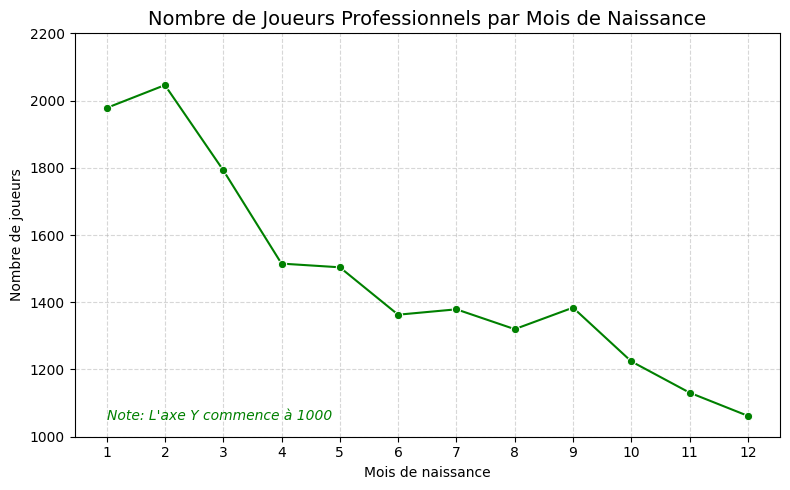

In [632]:
import math


# Graph 1: Number of Players by Birth Month (Line Plot with Markers)
plt.figure(figsize=(8, 5))

# Count the number of players per birth month 
month_counts = df["birth_month"].value_counts().sort_index()

# Line plot in green, for football
sns.lineplot(x=month_counts.index, y=month_counts.values, marker="o", linestyle="-", color="green")

# Set the y-axis limits
y_lower_limit = 1000
y_max_rounded = math.ceil(month_counts.max() / 100.0) * 100 + 100

plt.ylim(y_lower_limit, y_max_rounded)
plt.yticks(np.arange(y_lower_limit, y_max_rounded + 1, 200))


# Add explanatory note in green
plt.text(1, y_lower_limit + 50, f"Note: L'axe Y commence à {y_lower_limit}", 
         fontsize=10, color="green", style="italic")

# Titles and labels
plt.title("Nombre de Joueurs Professionnels par Mois de Naissance", fontsize=14)
plt.xlabel("Mois de naissance")
plt.ylabel("Nombre de joueurs")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Distribution by Quarter

To better visualise the effect, we grouped birth months into quarters. This pie chart shows a clear concentration in the **first quarter (January - March)**, where about **one third of players** are found, compared with less than 20% in the last quarter.

This confirms a **significant imbalance** in the distribution of birth dates, consistent with research on the RAE.


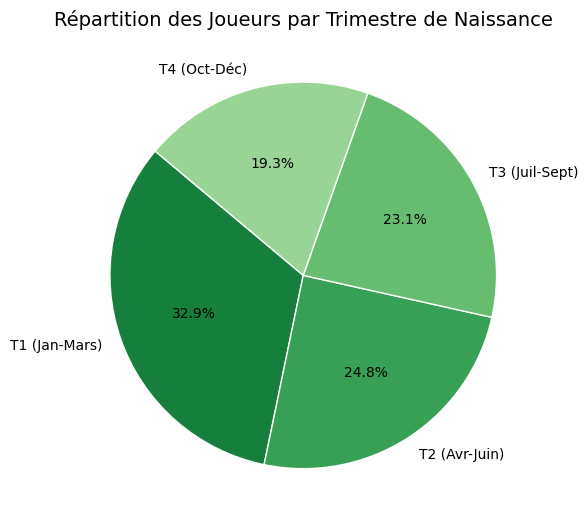

In [633]:
# Graph 2: Distribution of Players by Birth Quarter (Pie Chart)
plt.figure(figsize=(6, 6))
colors = plt.cm.Greens(np.linspace(0.8, 0.4, 4))  # Inverse on purpose: 0.8 is darkest

# Define the birth quarters
df["birth_quarter"] = pd.cut(
    df["birth_month"],
    bins=[0, 3, 6, 9, 12],
    labels=["T1 (Jan-Mars)", "T2 (Avr-Juin)", "T3 (Juil-Sept)", "T4 (Oct-Déc)"]
)

# Count the number of players per birth quarter
quarter_counts = df["birth_quarter"].value_counts()

# Sort the quarters by count
sorted_quarters = quarter_counts.sort_values(ascending=False)
sorted_labels = sorted_quarters.index
sorted_values = sorted_quarters.values

# Titles and labels
plt.pie(
    sorted_values,
    labels=sorted_labels,
    autopct='%1.1f%%', # Note: percentages are rounded to one decimal, so the total can be slightly below 100%
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.title("Répartition des Joueurs par Trimestre de Naissance", fontsize=14)
plt.tight_layout()
plt.show()


## Market Value by Birth Month

Now, to answer our main question, this last chart explores whether players born early in the year also have a **higher market value**.

We represented the distribution of market values by birth month as **box plots**, with a **logarithmic scale** to better show the differences.

The **median values** remain very close across the different months, which suggests that even though birth month influences the chances of reaching professional level (see the previous charts), it **does not directly affect the economic value of the player** once that step has been taken.


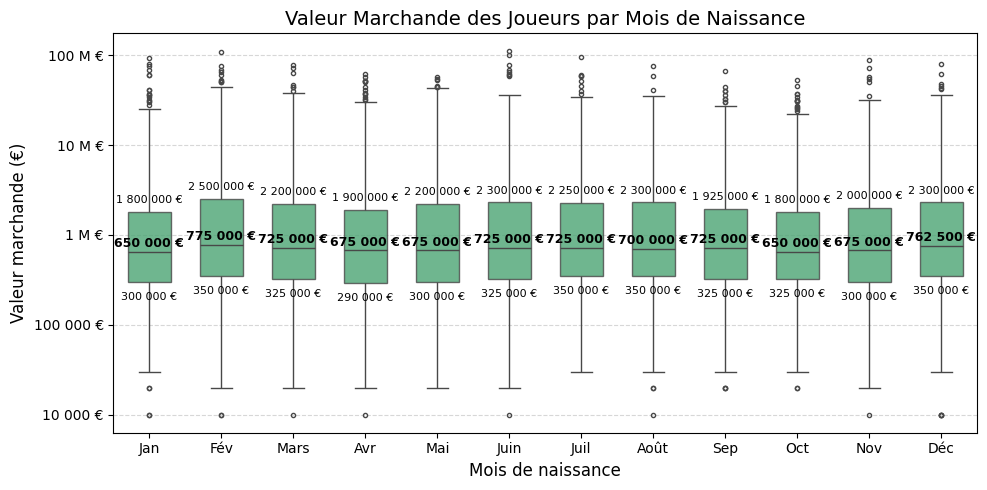

In [634]:
# Graph 3: Box Plot of Player Market Value by Birth Month
plt.figure(figsize=(10, 5))

# Copy the original DataFrame to avoid modifying the original
df_value_log = df.copy()

# Convert the value to log10 for better visualization, since the values are spread out
df_value_log["log_value"] = np.log10(df_value_log["value_euro"])

# Quartiles and medians per birth month
q1s = df_value_log.groupby("birth_month")["value_euro"].quantile(0.25)
q3s = df_value_log.groupby("birth_month")["value_euro"].quantile(0.75)
medians = df_value_log.groupby("birth_month")["value_euro"].median()

# Box plot with seaborn
ax = sns.boxplot(
    x="birth_month",
    y="log_value",
    data=df_value_log,
    color="mediumseagreen",
    width=0.6,
    boxprops={'alpha': 0.8},
    fliersize=3
)

# Set the y-axis ticks and labels
y_ticks = [4, 5, 6, 7, 8]
y_labels = ['10 000 €', '100 000 €', '1 M €', '10 M €', '100 M €']
plt.yticks(ticks=y_ticks, labels=y_labels)

# Add the median values as text on the plot
for i, month in enumerate(sorted(df_value_log["birth_month"].unique())):
    q1 = q1s[month]
    q3 = q3s[month]
    med = medians[month]
    
    # Positions on the log10 scale
    log_q1 = np.log10(q1)
    log_q3 = np.log10(q3)
    log_med = np.log10(med)
    
    # Labels
    label_q1 = f"{int(q1):,} €".replace(",", " ")
    label_q3 = f"{int(q3):,} €".replace(",", " ")
    label_med = f"{int(med):,} €".replace(",", " ")

    plt.text(i, log_q1 - 0.2, label_q1, ha='center', fontsize=8, color='black')
    plt.text(i, log_med + 0.05, label_med, ha='center', fontsize=9, color='black', weight='bold')
    plt.text(i, log_q3 + 0.1, label_q3, ha='center', fontsize=8, color='black')

# Titles and labels
plt.title("Valeur Marchande des Joueurs par Mois de Naissance", fontsize=14)
plt.xlabel("Mois de naissance", fontsize=12)
plt.ylabel("Valeur marchande (€)", fontsize=12)
plt.xticks(ticks=range(12), labels=["Jan", "Fév", "Mars", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"])
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#### We observe that although players born early in the year are more numerous, this does not necessarily translate into a higher market value. The distributions are broadly similar, which suggests that the relative age effect acts more as a \textit{barrier to entry} into the profession than as a determinant of performance or economic value.